#Regresión Polinomica
Se desea predecir el precio de venta de un auto en base a características como tipo de transmisión, kilometraje, y valor de mercado actual entre otras.

---
##Exploración de datos

Se cargo la data del archivo 'car_data', de manera de eliminar las columnas pertenecientes al nombre del auto y su dueño. Luego, mediante la columna 'set' se pudo ver que hay tres tipos de datos, los de entrenamiento, testeo y validación.



*   El **conjunto de entrenamiento**, son los datos utilizados para el aprendizaje del modelo, estos minimizan el riesgo empirico.
*   El **conjunto de validación**, son los datos utilizados para comparar modelos.
*  El **conjunto de testeo** son los datos utilizados para evaluar el desempeño final del algoritmo.

El siguiente paso fue indicar mediante probabilidades la proporción de variables categoricas. Las **variables categoricas** son variables que no tienen un valor numérico, sino que representan etiquetas o grupos. En nuestra matriz de datos las variables categoricas son:
* Fuel_type
* Seller_type
* Transmission
* Year









In [ ]:
!wget https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/car_data.csv
!file car_data.csv

--2025-09-03 21:32:44--  https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/car_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18812 (18K) [text/plain]
Saving to: ‘car_data.csv.6’

car_data.csv.6      100%[===================>]  18.37K  --.-KB/s    in 0.001s  

2025-09-03 21:32:44 (25.2 MB/s) - ‘car_data.csv.6’ saved [18812/18812]

car_data.csv: CSV text


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn import set_config

In [ ]:
car_data = pd.read_csv("/content/car_data.csv")

car_data = car_data.drop(columns = ["Car_Name", "Owner"]) #Elimina las columnas del nombre del auto y el dueño

#Conjunto de datos de entrenamiento
Train = car_data[car_data["Set"] == "Train"].drop(columns = ["Set"])  #En la columna Set filtra por Train los datos, y despues se elimina la columna Set

#Conjunto de datos de testeo
Test = car_data[car_data["Set"] == "Test"].drop(columns = ["Set"])

#Conjunto de datos de validación
Validation = car_data[car_data["Set"] == "Validation"].drop(columns = ["Set"])

#Columnas categoricas

car_categoricas = Train.select_dtypes(include=["object", "category"]).columns.tolist() #Filtra por las columnas que tienen datos de tipo categorico

for cate in car_categoricas:
    print(f"\nProporción de:",Train[cate].value_counts(normalize=True))#value_counts(normalize=True) me devuelve la probabilidad de cada categoria



Proporción de: Fuel_Type
Petrol    0.796296
Diesel    0.196296
CNG       0.007407
Name: proportion, dtype: float64

Proporción de: Seller_Type
Dealer        0.633333
Individual    0.366667
Name: proportion, dtype: float64

Proporción de: Transmission
Manual       0.859259
Automatic    0.140741
Name: proportion, dtype: float64


##Pre-procesamiento

En la etapa de **pre-procesamiento** la idea es transformar las variables originales en un conjunto de datos númericos adecuados para ser utilizados en un modelo de regresión. Como primer paso, codificamos las variables categoicas mediante *OneHotEncoder*, aquellas variables con dos clases se representan como una sola variable binaria de manera que se genera una sola columna binaria que toma el valor 0 o 1, mientras que las variables con más de dos clases se codifican mediante la técnica one-hot, generando una columna como categorias distintas. De esta manera, toda la información categórica queda expresada en forma numérica.

En segundo lugar, se aplica expansión polinómica mediante *PolynomialFeatures* de orden 3 sobre las variables numéricas. Esta transformación expande el conjunto de variables numéricas originales generando términos cuadráticos, cúbicos e interacciones entre ellas, lo cual permite que el modelo capture relaciones no lineales entre las características y el precio de venta.

Luego, se emplea un *ColumnTransformer* para combinar las distintas salidas:las variables categóricas codificadas en forma binaria y one-hot, junto con las variables numéricas expandidas polinómicamente. Como último paso, se aplica una normalización mediante *StandardScaler*, que ajusta todas las variables resultantes para que tengan media cero y varianza unitaria. Esta normalización es fundamental porque garantiza que todas las características estén en la misma escala, evitando que aquellas con valores numéricamente grandes dominen el ajuste del modelo.


In [ ]:
target_column = 'Selling_Price'

X_train = Train.drop(target_column, axis=1)
y_train = Train[target_column]

# 1. ONEHOTENCODER: Clasificar variables categóricas por número de clases
categorical_binario = []
categorical_onehot = []

for col in car_categoricas:
    unique_values = X_train[col].nunique()
    if unique_values == 2:
        categorical_binario.append(col)
    else:
        categorical_onehot.append(col)

numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Para binarias: drop='if_binary' mantiene solo una columna (0 o 1)
encoder = OneHotEncoder(drop='if_binary', sparse_output=False)

# Para múltiples
#multi_encoder = OneHotEncoder( sparse_output=False)
poly_features = PolynomialFeatures(degree=3, include_bias=False)

# 3. COLUMNTRANSFORMER: Combinar transformaciones
transformers = []

transformers.append(('binario', encoder, car_categoricas))
#transformers.append(('one-hot', encoder, categorical_onehot))
transformers.append(('poly_num', poly_features, numerical_features))

preprocessor = ColumnTransformer(
    transformers=transformers,
)

# 4. STANDARDSCALER: Normalización final
scaler = StandardScaler()

# combina y normaliza
preprocessing_pipeline = Pipeline([
    ('preprocessor', preprocessor),  # Combina todas las transformaciones
    ('scaler', scaler)              # Normaliza todo junto
])



##Regresión lineal

Una vez definido el preprocesamiento, el código implementa un pipeline completo de machine learning que combina las transformaciones anteriores con un modelo de regresión lineal. Para ello se utilizó la clase *Pipeline* de *scikit-learn*, incorporando en una primera etapa el pipeline de preprocesamiento y, como etapa final, el estimador *LinearRegression*. Esta estructura permite que con una sola llamada a fit() se ejecute todo el flujo de transformación y entrenamiento.
Para preparar los datos, se separan las features (X_Valid) del target (y_valid) del conjunto de validación, manteniendo la misma estructura que se usó para entrenamiento. La separación es fundamental porque las features necesitan preprocesamiento mientras que la variable objetivo se mantiene en su forma original para poder comparar las predicciones.
El entrenamiento se realiza con model.fit(X_train, y_train), que internamente ejecuta primero el preprocesamiento de las features y luego ajusta la regresión lineal con los datos transformados.

Para determinar el número de parámetros del modelo, se calcula la cantidad de features después del preprocesamiento y se suma 1 por el intercepto. LinearRegression tiene un coeficiente por cada feature más un término independiente (intercepto), siguiendo la ecuación y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ, donde β₀ es el intercepto y β₁ a βₙ son los coeficientes de las features.
Por lo tanto, el modelo resultante posee tantos parámetros como columnas tenga la matriz de características generada tras el preprocesamiento, más uno correspondiente al intercepto.

El diagrama visual se genera configurando *sklearn* con *set_config*(display='diagram') y usando display(model), lo que muestra una representación gráfica del flujo completo del pipeline desde datos de entrada hasta predicción final.
Finalmente, la evaluación se realiza calculando el error cuadrático medio (MSE) tanto en entrenamiento como en validación. Para entrenamiento se usa model.predict(X_train) y se compara con y_train, mientras que para validación se usa model.predict(X_Valid) comparado con y_valid. La diferencia entre ambos MSE indica si el modelo está overfitting (MSE validación mucho mayor que entrenamiento) o si generaliza bien (MSE similares).


In [ ]:
model = Pipeline([
    ('preprocessing', preprocessing_pipeline),  # tu pipeline anterior
    ('regression', LinearRegression())          # regresión lineal
])

X_Valid = Validation.drop(target_column, axis=1)
y_valid = Validation[target_column]

#Chequeo de parametros
model.fit(X_train, y_train)
n_features = preprocessor.fit_transform(X_train).shape[1]

n_parameters = n_features + 1
print(f"Parámetros del modelo: {n_parameters} ({n_features} coeficientes + 1 intercepto)")

set_config(display='diagram')
display(model)

# Entrenamiento
y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_train_pred)

# Validación
y_val_pred = model.predict(X_Valid)
mse_val = mean_squared_error(y_valid, y_val_pred)

print(f"MSE entrenamiento: {mse_train:.4f}")
print(f"MSE validación: {mse_val:.4f}")

Parámetros del modelo: 25 (24 coeficientes + 1 intercepto)


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('preprocessor',
                                  ColumnTransformer(transformers=[('binario',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 sparse_output=False),
                                                                   ['Fuel_Type',
                                                                    'Seller_Type',
                                                                    'Transmission']),
                                                                  ('poly_num',
                                                                   PolynomialFeatures(degree=3,
                                                                                      include_bias=False),
                                                                   ['Year',
                                                                    'Present_Price',
                                                                    'Kms_Driven'])])),
                                 ('scaler', StandardScaler())])),
                ('regression', LinearRegression())])

MSE entrenamiento: 0.4727
MSE validación: 0.5420


##Regularización

Para implementar una regresión polinomica regularizada, se busco aplicar el método de regularización Ridge dentro de un Pipeline de sklearn. Este es un método destinado a combatir el ''overfitting', esto pasa cuando el modelo aprende muy bien de los datos de entrenamiento, tanto que no llega a generalizar los datos, esto hace que ante un cambio en la entrada el modelo no haga una buena predicción. Ridge trabaja con lo que es el la minimización del riesgo esperado donde λ es el hiper-parametro que controla el overfitting, haciendo que los parametros de mayor peso sean forzados a cero para simplificar el modelo.
El procedimiento comienza combinando el pipeline de preprocesamiento de datos con el modelo de Ridge, lo que permite integrar en un mismo flujo tanto la preparación de las variables como el ajuste del modelo. A continuación, se entrena la regresión regularizada para un conjunto de valores del hiperparámetro de penalización λ. Para cada valo de estos se calcula los MSE de entrenamiento y validación, el cual obtenemos que tienen un GAP de aprox
 Para cada valor de 2.1e-1. Luego, se grafican las curvas de MSE en función de
λ, de modo de visualizar la evolución del error a medida que λ aumenta, además de la discrepancia entre los datos entrenados y los de validación.
Luego de obtener estas métricas, se determina el valor de λ que minimiza el error de validación. Finalmente con este valor, se vuelve a entrenar el modelo y se calcula el MSE sobre el conjunto de testeo, también graficandolo, el cual representa la métrica final de desempeño y permite estimar la capacidad del modelo a generalizar frente a nuevos datos. Como podemos ver el comportamiento ante λ se puede ver como aproximadamente proporcional al comportamiento de los datos de validación, por lo que podemos decir que en base a esto, el modelo generaliza bien los datos capturados.



λ óptimo: 2.07e-04
MSE testeo: 0.3371


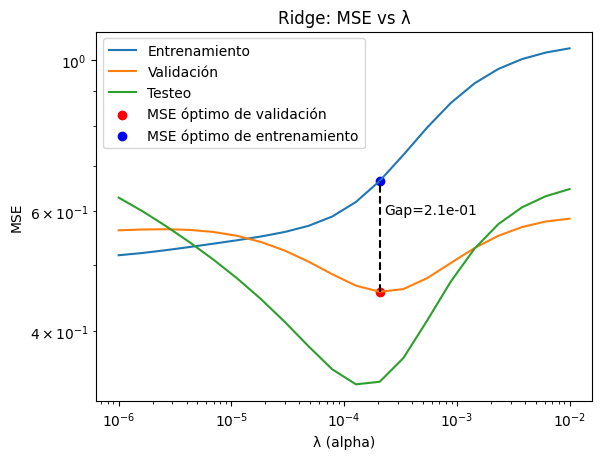

In [ ]:
ridge_model = Pipeline([
    ('preprocessing', preprocessing_pipeline),  # tu pipeline anterior
    ('ridge', Ridge())                          # regresión Ridge
])

lambdas = np.logspace(-6, -2, 20)  # 20 valores entre 1e-6 y 1e-2
mse_train = []
mse_val = []

for lam in lambdas:
    ridge_model.set_params(ridge__alpha=lam)
    ridge_model.fit(X_train, y_train)

    # MSE entrenamiento
    y_train_pred = ridge_model.predict(X_train)
    mse_train.append(mean_squared_error(y_train, y_train_pred))

    # MSE validación
    y_val_pred = ridge_model.predict(X_Valid)
    mse_val.append(mean_squared_error(y_valid, y_val_pred))

# 4. λ óptimo
best_idx = np.argmin(mse_val)
best_lambda = lambdas[best_idx]
print(f"λ óptimo: {best_lambda:.2e}")

# 5. MSE testeo
X_Test = Test.drop(target_column, axis=1)
y_test = Test[target_column]

ridge_model.set_params(ridge__alpha=best_lambda)
ridge_model.fit(X_train, y_train)
y_test_pred = ridge_model.predict(X_Test)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"MSE testeo: {mse_test:.4f}")
mse_test = []

for lam in lambdas:
  ridge_model.set_params(ridge__alpha=lam)
  ridge_model.fit(X_train, y_train)

  # MSE entrenamiento
  y_test_pred = ridge_model.predict(X_Test)
  mse_test.append(mean_squared_error(y_test, y_test_pred))


#Gráfico
plt.loglog(lambdas, mse_train, label='Entrenamiento')
plt.loglog(lambdas, mse_val, label='Validación')
plt.loglog(lambdas, mse_test, label='Testeo')
plt.scatter(best_lambda, mse_val[best_idx], color="red", label="MSE óptimo de validación")
plt.scatter(best_lambda, mse_train[best_idx], color="blue", label="MSE óptimo de entrenamiento")
plt.plot([best_lambda, best_lambda],
         [mse_val[best_idx], mse_train[best_idx]],
         linestyle="--", color="black")
GAP = mse_train[best_idx] - mse_val[best_idx]
plt.text(best_lambda*1.1, mse_val[best_idx]*1.3, f"Gap={GAP:.1e}", color="black")
plt.xlabel('λ (alpha)')
plt.ylabel('MSE')
plt.title('Ridge: MSE vs λ')
plt.legend()
plt.show()

